# Subject Level GNN (Tuned)

This is the final GNN model. Aggregated at the subject level and hyperparameter tuned.

## Setup

In [1]:
# Get content from Drive
from google.colab import drive
drive.mount('/content/drive')

# Get GitHub token from Colab secrets
from google.colab import userdata
token = userdata.get('github_token')

# Clone the repo if it doesn't exist. Pull the latest otherwise
import os
if not os.path.exists('/content/agnn'):
    !git clone https://{token}@github.com/charlottedavidson524/alzheimers-gnn.git /content/agnn
%cd /content/agnn
!git pull

# nstall project. Need to do this after a fresh clone
!pip install -e . --quiet
!pip install torch-geometric --quiet

# Copy subject-level graphs to local storage for faster access
if not os.path.exists("/content/graphs_subject"):
    !cp -r /content/drive/MyDrive/alzheimers-gnn-data/graphs_subject /content/graphs_subject
if not os.path.exists("/content/participants.tsv"):
    !cp /content/drive/MyDrive/alzheimers-gnn-data/participants.tsv /content/participants.tsv

# GPU check
import torch
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Not available'}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/agnn
Already up to date.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for agnn (pyproject.toml) ... done
GPU: Tesla T4


Now that everything is setup correctly, move onto the imports

In [2]:
import json
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score, confusion_matrix
from agnn.paths import get_results_root
from agnn.gnn.model import MultiBandGCN
from agnn.gnn.data import load_subject_graphs, pair_by_subject, make_cv_splits, make_dataloader, verify_no_subject_leakage
from agnn.gnn.train import train_fold, set_seed

# Check what device is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Make sure thius points at the subject level graphs directory, not per epoch
GRAPHS_ROOT = Path("/content/graphs_subject")
print(f"Graphs root: {GRAPHS_ROOT}")

Device: cuda
Graphs root: /content/graphs_subject


Using cuda and is pointing at subject level graphs directory. Can move on to the new config.

In [3]:
config = {
    # Model hyperparameters
    "hidden_channels": 32,
    "embedding_dim": 32,
    "mlp_hidden": 32,
    "dropout": 0.6,

    # Training hyperparameters
    "learning_rate": 0.0003,
    "weight_decay": 0.001,
    "batch_size": 8,
    "epochs": 300,
    "patience": 20,
    "class_weights": [1.5, 1.0],

    # Cross-validation
    "n_folds": 5,
    "seed": 42,
}

# Print config to check eveerything looks right
print("Config:")
for k, v in config.items():
    print(f"  {k}: {v}")

Config:
  hidden_channels: 32
  embedding_dim: 32
  mlp_hidden: 32
  dropout: 0.6
  learning_rate: 0.0003
  weight_decay: 0.001
  batch_size: 8
  epochs: 300
  patience: 20
  class_weights: [1.5, 1.0]
  n_folds: 5
  seed: 42


What has changed with regards to the hyperparamaters:

- The model hyperparameters have been kept the same as per epoch.

- However the training hyperparameters have been adjusted because the dataset is smaller and there are only 77 samples. Batch size has been cut bnecause of fewer training samples per fold and epochs are higher because there is less data per epoch.

Now load and pair subjects, using pair_by_subject() this time instead of pair_by_epoch().

In [4]:
# Find all the subject folders in the subject level graph directory
subjects = sorted([d.name for d in GRAPHS_ROOT.iterdir() if d.is_dir()])
print(f"Found {len(subjects)} subjects at {GRAPHS_ROOT}")

# Load and pair all graphs by subject. Each subject should have two graphs, delta and alpha-2/
graphs = load_subject_graphs(subjects, GRAPHS_ROOT)
pairs = pair_by_subject(graphs)

# Check on the cohort summary
n_positive = sum(p[2] for p in pairs)
print(f"Total pairs: {len(pairs)}")
print(f"Positive class (carriers): {n_positive} ({n_positive/len(pairs):.1%})")
print(f"Negative class (non-carriers): {len(pairs)-n_positive} ({(len(pairs)-n_positive)/len(pairs):.1%})")

Found 77 subjects at /content/graphs_subject
Total pairs: 77
Positive class (carriers): 46 (59.7%)
Negative class (non-carriers): 31 (40.3%)


found 77 subjects and 77 pairs as expected. Class balance is correct and in line with what is known. Move on to creating CV splits and the results directory.

In [5]:
# Create CV splits at the subject level where each pair is a subject
set_seed(config["seed"])
splits = make_cv_splits(pairs, n_folds=config["n_folds"], seed=config["seed"])
print(f"Created {len(splits)} folds")

# This code creates timestamped results directory in Drive (this is useful to see whats happening when)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = get_results_root()/f"run_subject_{timestamp}"
run_dir.mkdir(parents=True, exist_ok=True)
print(f"Results will save to: {run_dir}")

# Save config used for this run
with open(run_dir/"config.json", "w") as f:
    json.dump(config, f, indent=2)

Created 5 folds
Results will save to: /content/drive/MyDrive/alzheimers-gnn-data/results/run_subject_20260805_142229


Now run the 5 fold CV

In [6]:
# Empty list to store fold results
fold_results = []

# Main CV loop. Each iteration trains and evaluates one fold end-to-end.
for fold_idx, (train_idx, val_idx) in enumerate(splits):
    print(f"\n{'='*60}")
    print(f"Fold {fold_idx+1}/{config['n_folds']}")
    print(f"{'='*60}")

    # Use the defensive leakage check function created earlier to check for subject leakage
    verify_no_subject_leakage(pairs, train_idx, val_idx)

    # Report fold composition
    train_labels = [pairs[i][2] for i in train_idx]
    val_labels = [pairs[i][2] for i in val_idx]
    train_subjects = {pairs[i][0].subject_id for i in train_idx}
    val_subjects = {pairs[i][0].subject_id for i in val_idx}

    # For both train and validation datasets, record the number of pairs, subjects, and percentage of carriers
    print(f"Train: {len(train_idx)} pairs, {len(train_subjects)} subjects, {sum(train_labels)}/{len(train_labels)} positive ({sum(train_labels)/len(train_labels):.1%})")
    print(f"Val: {len(val_idx)} pairs, {len(val_subjects)} subjects, {sum(val_labels)}/{len(val_labels)} positive ({sum(val_labels)/len(val_labels):.1%})")

    # Fresh model per fold to ensure independent training
    set_seed(config["seed"]+fold_idx) # different seed per fold, but reproducible

    # Model. Values come from the config
    model = MultiBandGCN(hidden_channels=config["hidden_channels"], embedding_dim=config["embedding_dim"], mlp_hidden=config["mlp_hidden"],
                         dropout=config["dropout"]).to(device)

    # Create train and validation loaders for the fold
    train_loader = make_dataloader(pairs, train_idx, batch_size=config["batch_size"], shuffle=True)
    val_loader = make_dataloader(pairs, val_idx, batch_size=config["batch_size"], shuffle=False)

    # Create fold directory for outputs
    fold_dir = run_dir/f"fold_{fold_idx}"
    fold_dir.mkdir(exist_ok=True)

    # Train this fold
    result = train_fold(model=model, train_loader=train_loader, val_loader=val_loader, config=config, device=device,
        checkpoint_path=fold_dir/"best_model.pt", verbose=True)

    # Save the training history. Use it to plot curves later on
    with open(fold_dir/"history.json", "w") as f:
        json.dump(result["history"], f, indent=2)

    # Save predictions at best epoch. used later for downstream metrics
    np.savez(fold_dir/"predictions.npz", y_true=result["best_metrics"]["y_true"], y_prob=result["best_metrics"]["y_prob"])

    # Save a fold level metrics summary
    y_true = result["best_metrics"]["y_true"]
    y_prob = result["best_metrics"]["y_prob"]
    y_pred = (y_prob > 0.5).astype(int)

    # Collect the metrics and metadata into a dictionary for this particular fold
    fold_summary = {
        "fold": fold_idx,
        "best_auc": result["best_auc"],
        "best_epoch": result["best_epoch"],
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "n_train": len(train_idx),
        "n_val": len(val_idx),
        "n_train_subjects": len(train_subjects),
        "n_val_subjects": len(val_subjects),
    }

    # Save the fold summary to disk. Allows for later analysis
    with open(fold_dir/"metrics.json", "w") as f:
        json.dump(fold_summary, f, indent=2)


    # Append to the running list created at the beginning. Used later for cross-fold aggregation.
    fold_results.append(fold_summary)

    print(f"\nFold {fold_idx + 1} complete: AUC = {result['best_auc']:.4f} at epoch {result['best_epoch']}")


Fold 1/5
Train: 61 pairs, 61 subjects, 37/61 positive (60.7%)
Val: 16 pairs, 16 subjects, 9/16 positive (56.2%)
Epoch   1/300: train_loss=0.6948, val_loss=0.6986, val_auc=0.4286
Epoch   2/300: train_loss=0.6980, val_loss=0.6985, val_auc=0.4286
Epoch   3/300: train_loss=0.6939, val_loss=0.6982, val_auc=0.4286
Epoch   4/300: train_loss=0.6989, val_loss=0.6980, val_auc=0.4286
Epoch   5/300: train_loss=0.6907, val_loss=0.6978, val_auc=0.4286
Epoch   6/300: train_loss=0.6959, val_loss=0.6977, val_auc=0.4286
Epoch   7/300: train_loss=0.6937, val_loss=0.6976, val_auc=0.4286
Epoch   8/300: train_loss=0.6934, val_loss=0.6974, val_auc=0.4286
Epoch   9/300: train_loss=0.6961, val_loss=0.6972, val_auc=0.4286
Epoch  10/300: train_loss=0.6965, val_loss=0.6969, val_auc=0.4286
Epoch  11/300: train_loss=0.6921, val_loss=0.6968, val_auc=0.4286
Epoch  12/300: train_loss=0.6967, val_loss=0.6964, val_auc=0.4286
Epoch  13/300: train_loss=0.6954, val_loss=0.6963, val_auc=0.4286
Epoch  14/300: train_loss=0.6

Fold level results already looking improved, however check other metrics. Below is the aggregated cross fold metrics

In [7]:
# Build cross-fold summary df
summary_df = pd.DataFrame(fold_results)
summary_df.to_csv(run_dir/"cross_fold_metrics.csv", index=False)
print("Cross-fold metrics:")
print(summary_df.to_string(index=False))

# Create overall statistics
mean_auc = summary_df["best_auc"].mean()
std_auc = summary_df["best_auc"].std()
mean_f1 = summary_df["f1"].mean()

# Show a printed summary
print(f"\n{'='*60}")
print(f"Cross-fold summary (subject level, n_folds={config['n_folds']})")
print(f"{'='*60}")
print(f"AUC: {mean_auc:.4f} +/- {std_auc:.4f}")
print(f"F1: {mean_f1:.4f} +/- {summary_df['f1'].std():.4f}")
print(f"Precision: {summary_df['precision'].mean():.4f} +/- {summary_df['precision'].std():.4f}")
print(f"Recall: {summary_df['recall'].mean():.4f} +/- {summary_df['recall'].std():.4f}")

# Save top-level summary
top_summary = {
    "config": config,
    "aggregation": "subject-level",
    "n_subjects": len(subjects),
    "n_pairs": len(pairs),
    "class_balance": {
        "positive": n_positive,
        "negative": len(pairs) - n_positive,
        "ratio_pos": n_positive / len(pairs),
    },
    "cross_fold_auc": {
        "mean": float(mean_auc),
        "std": float(std_auc),
        "per_fold": summary_df["best_auc"].tolist(),
    },
    "cross_fold_f1": {
        "mean": float(mean_f1),
        "std": float(summary_df["f1"].std()),
    },
}

# Write the top level summary to the disk in Drive so it can survive session end
with open(run_dir/"summary.json", "w") as f:
    json.dump(top_summary, f, indent=2)

print(f"\nAll results saved to: {run_dir}")

Cross-fold metrics:
 fold  best_auc  best_epoch  precision  recall       f1  n_train  n_val  n_train_subjects  n_val_subjects
    0  0.730159          28      0.000     0.0 0.000000       61     16                61              16
    1  0.950000           1      0.625     1.0 0.769231       61     16                61              16
    2  0.537037           1      0.000     0.0 0.000000       62     15                62              15
    3  0.722222           8      0.600     1.0 0.750000       62     15                62              15
    4  0.333333           1      0.600     1.0 0.750000       62     15                62              15

Cross-fold summary (subject level, n_folds=5)
AUC: 0.6546 +/- 0.2316
F1: 0.4538 +/- 0.4144
Precision: 0.3650 +/- 0.3334
Recall: 0.6000 +/- 0.5477

All results saved to: /content/drive/MyDrive/alzheimers-gnn-data/results/run_subject_20260805_142229


Show the training curves

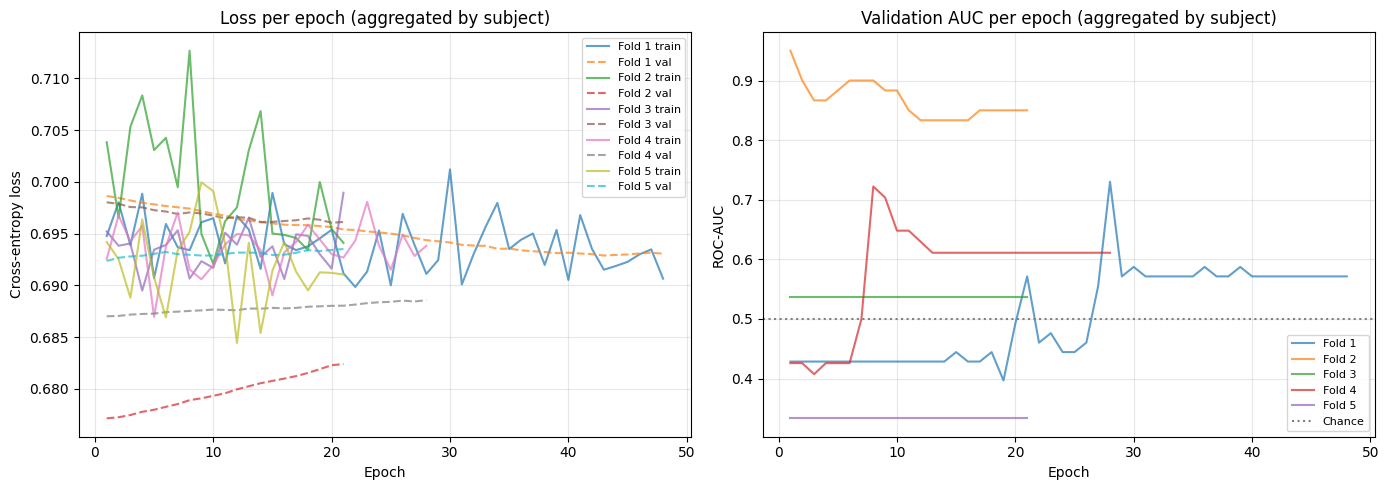

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Iterate over the folds. Log each fold's saved history and plot its curves.
for fold_idx in range(config["n_folds"]):
    fold_dir = run_dir/f"fold_{fold_idx}"
    with open(fold_dir/"history.json") as f:
        history = json.load(f)

    # Left axis will be train/validation loss curves. Right will be validation AUC
    epochs = range(1, len(history["train_loss"])+1)
    axes[0].plot(epochs, history["train_loss"], label=f"Fold {fold_idx+1} train", alpha=0.7)
    axes[0].plot(epochs, history["val_loss"], label=f"Fold {fold_idx+1} val", linestyle="--", alpha=0.7)
    axes[1].plot(epochs, history["val_auc"], label=f"Fold {fold_idx+1}", alpha=0.7)

# Title, labels, legend and grid for left hand graph
axes[0].set_title("Loss per epoch (aggregated by subject)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend(fontsize=8, loc="upper right")
axes[0].grid(alpha=0.3)

# Title, labels, legend and grid for right hand graph
axes[1].set_title("Validation AUC per epoch (aggregated by subject)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ROC-AUC")
axes[1].axhline(y=0.5, color="gray", linestyle=":", label="Chance")
axes[1].legend(fontsize=8, loc="lower right")
axes[1].grid(alpha=0.3)

# Display and save graphs
plt.tight_layout()
plt.savefig(run_dir/"training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

ROC curves plot

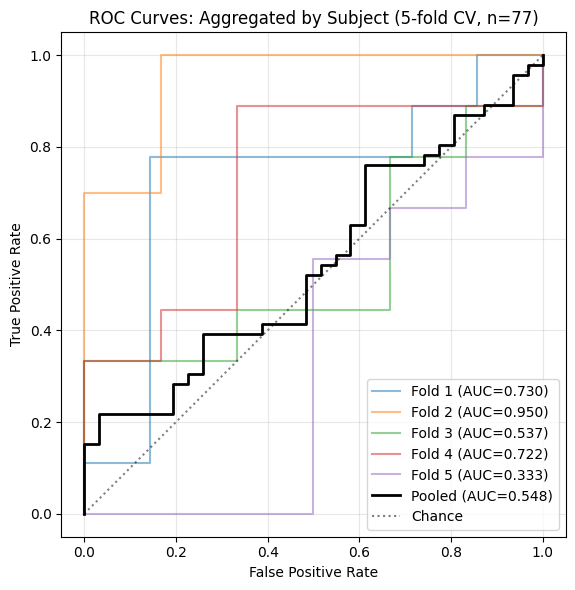

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))

# Plot the ROC curve for each fold individually, this shows the variation between folds
for fold_idx in range(config["n_folds"]):
    fold_dir = run_dir/f"fold_{fold_idx}"
    preds = np.load(fold_dir/"predictions.npz")
    fpr, tpr, _ = roc_curve(preds["y_true"], preds["y_prob"])
    auc = roc_auc_score(preds["y_true"], preds["y_prob"])
    ax.plot(fpr, tpr, alpha=0.5, label=f"Fold {fold_idx+1} (AUC={auc:.3f})")

# Prepare lists to collect predictions across folds for the pooled ROC
all_y_true = []
all_y_prob = []

# Load each fold's predictions and append to the running lsist
for fold_idx in range(config["n_folds"]):
    preds = np.load(run_dir/f"fold_{fold_idx}"/"predictions.npz")
    all_y_true.append(preds["y_true"])
    all_y_prob.append(preds["y_prob"])

# Flatten into single arrays covering the whole cohort
all_y_true = np.concatenate(all_y_true)
all_y_prob = np.concatenate(all_y_prob)

# Compute the pooled ROC and AUC across all folds combined
fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
pooled_auc = roc_auc_score(all_y_true, all_y_prob)

# Draw the pooled ROC on top of the per-fold curves. This should give a cohort-level view
ax.plot(fpr, tpr, color="black", linewidth=2, label=f"Pooled (AUC={pooled_auc:.3f})")

# The chance line
ax.plot([0, 1], [0, 1], "k:", alpha=0.5, label="Chance")

# Labels, title, legend and grid for the plot
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curves: Aggregated by Subject (5-fold CV, n={len(subjects)})")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
ax.set_aspect("equal")

# Display and save plot
plt.tight_layout()
plt.savefig(run_dir/"roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()